# Hypothesis: expanding versus fixed dimensionality

This experiment tests whether retaining each projected tree representation is better than projecting every concatenation back to the same width. The train, validation, and test split is fixed once; only the forest and projection seed changes across repetitions.

In [1]:
import warnings
from sklearn.random_projection import DataDimensionalityWarning
warnings.filterwarnings(
    "ignore",
    category=DataDimensionalityWarning,
    message="The number of components is higher than the number of features.*",
)

from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists():
    notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))
from _hypothesis_utils import classification_data, forest_classifier, plot_critical_difference, serialized_size_mb
from recursivesketch import RecursiveSketchClassifier

In [2]:
DATA_SEED = 42
MODEL_SEEDS = list(range(8))
N_ITERATIONS = 2
X_train, X_val, X_test, y_train, y_val, y_test = classification_data(
    DATA_SEED, n_samples=1200, n_features=60
)
P = X_train.shape[1]
BLOCK_DIMENSION = 20 * P
print(f'Rule of thumb: p={P}, block d=20*p={BLOCK_DIMENSION}')
experiment_start = time.perf_counter()

def evaluate_mode(seed, dimension_mode, n_components, label=None):
    sketch = RecursiveSketchClassifier(
        estimator=forest_classifier(seed, n_estimators=100),
        n_components=n_components,
        n_iterations=N_ITERATIONS,
        dimension_mode=dimension_mode,
        random_state=seed,
    )
    start = time.perf_counter()
    X_train_sketch = sketch.fit_transform(X_train, y_train)
    X_test_sketch = sketch.transform(X_test)
    wall_seconds = time.perf_counter() - start
    downstream = LogisticRegression(max_iter=2000)
    downstream.fit(X_train_sketch, y_train)
    prediction = downstream.predict(X_test_sketch)
    return {
        'seed': seed,
        'mode': label or dimension_mode,
        'block_dimension': n_components,
        'output_dimension': X_train_sketch.shape[1],
        'accuracy': accuracy_score(y_test, prediction),
        'errors': int(np.count_nonzero(prediction != y_test)),
        'wall_seconds': wall_seconds,
        'serialized_mb': serialized_size_mb(sketch),
    }

results = []
for seed in MODEL_SEEDS:
    results.append(evaluate_mode(seed, 'fixed', BLOCK_DIMENSION))
    results.append(evaluate_mode(seed, 'expanding', BLOCK_DIMENSION))
    # Width-matched control: fixed mode receives the same final width as expanding mode.
    results.append(evaluate_mode(seed, 'fixed', BLOCK_DIMENSION * (N_ITERATIONS + 1), label='fixed-width-matched'))

results = pd.DataFrame(results)
experiment_wall_seconds = time.perf_counter() - experiment_start
results

Rule of thumb: p=60, block d=20*p=1200


,seed,mode,block_dimension,output_dimension,accuracy,errors,wall_seconds,serialized_mb
0,0,fixed,1200,1200,0.879167,29,1.592248,183.831537
1,0,expanding,1200,3600,0.875000,30,1.161841,176.289038
2,0,fixed-width-matched,3600,3600,0.870833,31,3.230231,495.727311
3,1,fixed,1200,1200,0.854167,35,1.062352,182.602533
4,1,expanding,1200,3600,0.879167,29,0.981219,174.422376
5,1,fixed-width-matched,3600,3600,0.887500,27,3.127613,501.017961
6,2,fixed,1200,1200,0.862500,33,1.067289,186.595290
7,2,expanding,1200,3600,0.870833,31,1.294087,177.081427
8,2,fixed-width-matched,3600,3600,0.862500,33,2.949586,494.526464
9,3,fixed,1200,1200,0.841667,38,1.150190,179.396688


In [3]:
summary = (
    results.groupby('mode')
    .agg(
        mean_accuracy=('accuracy', 'mean'),
        std_accuracy=('accuracy', 'std'),
        mean_errors=('errors', 'mean'),
        mean_wall_seconds=('wall_seconds', 'mean'),
        mean_serialized_mb=('serialized_mb', 'mean'),
        output_dimension=('output_dimension', 'first'),
        n=('accuracy', 'size'),
    )
    .reset_index()
)
summary['ci95_accuracy'] = 1.96 * summary['std_accuracy'] / np.sqrt(summary['n'])
print(f'Total experiment wall-clock time: {experiment_wall_seconds:.1f} seconds')
summary

Total experiment wall-clock time: 42.6 seconds


,mode,mean_accuracy,std_accuracy,mean_errors,mean_wall_seconds,mean_serialized_mb,output_dimension,n,ci95_accuracy
0,expanding,0.868750,0.017395,31.500,1.027461,176.054863,3600,8,0.012054
1,fixed,0.859896,0.021239,33.625,1.117853,184.226848,1200,8,0.014718
2,fixed-width-matched,0.876042,0.011519,29.750,2.888937,497.290687,3600,8,0.007982


In [4]:
paired = results.pivot(index='seed', columns='mode', values='accuracy')
paired['expanding_minus_fixed'] = paired['expanding'] - paired['fixed']
paired['expanding_minus_width_matched'] = (
    paired['expanding'] - paired['fixed-width-matched']
)
def paired_report(column):
    values = paired[column].to_numpy()
    mean = values.mean()
    half_width = 1.96 * values.std(ddof=1) / np.sqrt(values.size)
    return pd.Series({
        'mean_gain': mean,
        'std_gain': values.std(ddof=1),
        'ci95_low': mean - half_width,
        'ci95_high': mean + half_width,
        'n': values.size,
    })
paired_summary = pd.DataFrame({
    'expanding_vs_fixed': paired_report('expanding_minus_fixed'),
    'expanding_vs_width_matched': paired_report('expanding_minus_width_matched'),
}).T
paired_summary

,mean_gain,std_gain,ci95_low,ci95_high,n
expanding_vs_fixed,0.008854,0.011233,0.001070,0.016638,8.0
expanding_vs_width_matched,-0.007292,0.020260,-0.021331,0.006748,8.0


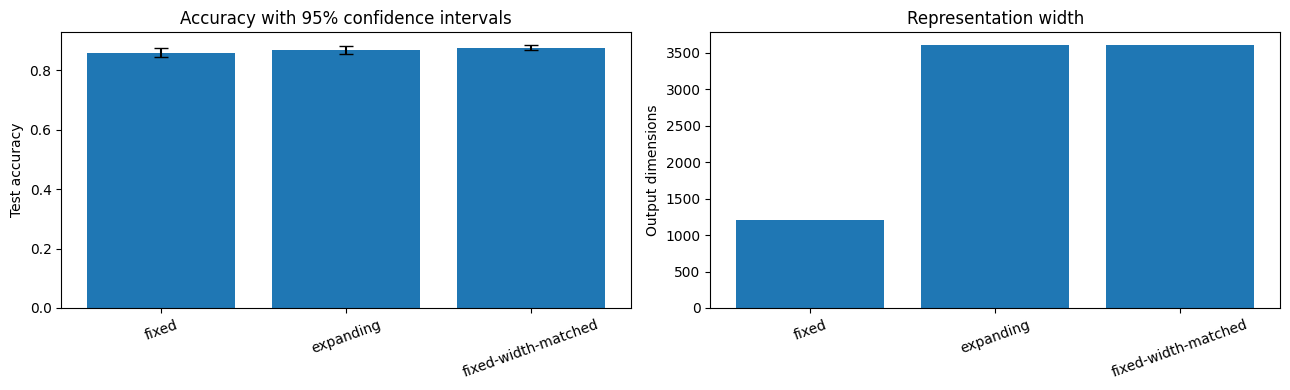

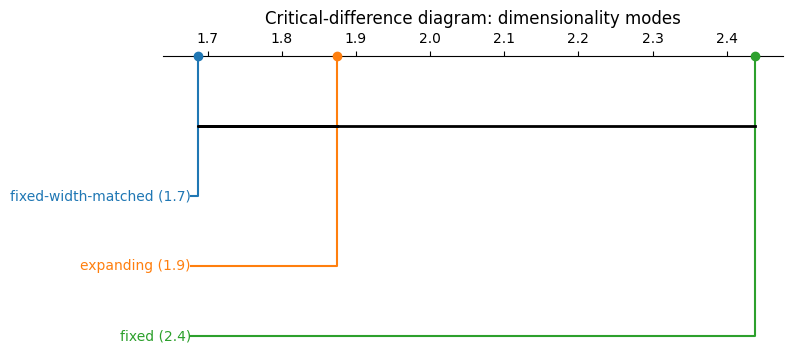

Hypothesis 8: INCONCLUSIVE — expanding minus fixed gain 0.009 (95% CI 0.001, 0.017); width-matched gain -0.007 (95% CI -0.021, 0.007)


In [5]:
labels = ['fixed', 'expanding', 'fixed-width-matched']
plot_summary = summary.set_index('mode').loc[labels]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(
    labels, plot_summary['mean_accuracy'],
    yerr=plot_summary['ci95_accuracy'], capsize=5,
)
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Accuracy with 95% confidence intervals')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(labels, plot_summary['output_dimension'])
axes[1].set_ylabel('Output dimensions')
axes[1].set_title('Representation width')
axes[1].tick_params(axis='x', rotation=20)
fig.tight_layout()
plt.show()

plot_critical_difference(
    results,
    block_column='seed',
    method_column='mode',
    title='Critical-difference diagram: dimensionality modes',
)
plt.show()

gain = paired_summary.loc['expanding_vs_fixed']
matched_gain = paired_summary.loc['expanding_vs_width_matched']
if gain['ci95_low'] > 0 and matched_gain['ci95_low'] > 0:
    verdict = 'SUPPORTED'
elif gain['ci95_high'] < 0 and matched_gain['ci95_high'] < 0:
    verdict = 'NOT SUPPORTED'
else:
    verdict = 'INCONCLUSIVE'
print(
    f'Hypothesis 8: {verdict} — expanding minus fixed gain '
    f"{gain['mean_gain']:.3f} (95% CI {gain['ci95_low']:.3f}, {gain['ci95_high']:.3f}); "
    f"width-matched gain {matched_gain['mean_gain']:.3f} "
    f"(95% CI {matched_gain['ci95_low']:.3f}, {matched_gain['ci95_high']:.3f})"
)

## Hypothesis, experiment, measure, and result

**Hypothesis.** Retaining each projected tree representation through concatenation, and therefore expanding the dimensionality by one block per iteration, improves held-out predictive performance over fixed-dimensional re-embedding.

**Experiment.** On one fixed noisy classification split, eight paired forest and projection seeds compare fixed mode at the initial block width, expanding mode at that same block width, and a width-matched fixed-mode control. The downstream classifier, forest configuration, and iteration count are held constant.

**Measure.** The primary measure is the paired test-accuracy gain with a 95% confidence interval. Output width, wall-clock fit time, and serialized estimator size are secondary measures.

**Result.** The executed verdict and paired confidence intervals are printed above. The width-matched comparison is the important control: a positive result only supports the hypothesis when the gain is reproducible there as well as against the narrower fixed representation.